
# Annual Seismic Energy Timeseries of the Indian Tectonic Plate using Seismicity Data

# Overview

This project presents a complete seismological workflow for:

- Earthquake catalogue preprocessing
- Seismic energy estimation
- Spatial seismicity visualization
- Annual seismic energy release analysis
- Indian tectonic plate seismicity assessment

The workflow combines empirical seismological equations with geospatial visualization techniques to analyze earthquake energy release over the Indian tectonic plate region.



# Theoretical Background

Equation (1):

$$
\log_{10}(M_0) = 1.5(M_w + 6.0)
$$

Equation (2):

$$
E_s = 1.6 \times 10^{-5}(M_0)
$$

Where:

- $M_0$ = Seismic Moment
- $M_w$ = Moment Magnitude
- $E_s$ = Seismic Energy


## 1. Import Required Libraries

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Install Basemap Dependencies

In [4]:
!apt-get install libgeos-dev -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgeos-dev is already the newest version (3.12.1-1~jammy0).
libgeos-dev set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [5]:
!pip install basemap basemap-data-hires

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.1
    Uninstalling packaging-26.1:
      Successfully uninstalled packaging-26.1


## 3. Import Basemap

In [1]:
from mpl_toolkits.basemap import Basemap

## 4. Load Earthquake Catalogue

In [4]:
data = pd.read_csv('/content/drive/MyDrive/Project 4/data.csv')

data.head()

,Longitude,Latitude,Decimal year,Month,Day,Magnitude,Depth,Hour,Minute,Second
0,95.96,3.03,1960.005376,1,2,5.0,0.0,5,6,0.0
1,94.70,6.53,1960.018817,1,7,5.9,0.0,8,15,0.0
2,94.68,6.67,1960.018817,1,7,6.0,0.0,23,17,0.0
3,70.08,36.47,1960.024194,1,9,6.7,231.0,7,24,0.0
4,95.99,16.10,1960.029570,1,11,5.8,0.0,3,10,0.0


## 5. Data Preprocessing

In [5]:
data = data.dropna(subset=['Longitude', 'Latitude', 'Magnitude'])

lon = data['Longitude']
lat = data['Latitude']
mag = data['Magnitude']

data.head()

,Longitude,Latitude,Decimal year,Month,Day,Magnitude,Depth,Hour,Minute,Second
0,95.96,3.03,1960.005376,1,2,5.0,0.0,5,6,0.0
1,94.70,6.53,1960.018817,1,7,5.9,0.0,8,15,0.0
2,94.68,6.67,1960.018817,1,7,6.0,0.0,23,17,0.0
3,70.08,36.47,1960.024194,1,9,6.7,231.0,7,24,0.0
4,95.99,16.10,1960.029570,1,11,5.8,0.0,3,10,0.0


## 6. Publication Quality Seismicity Map

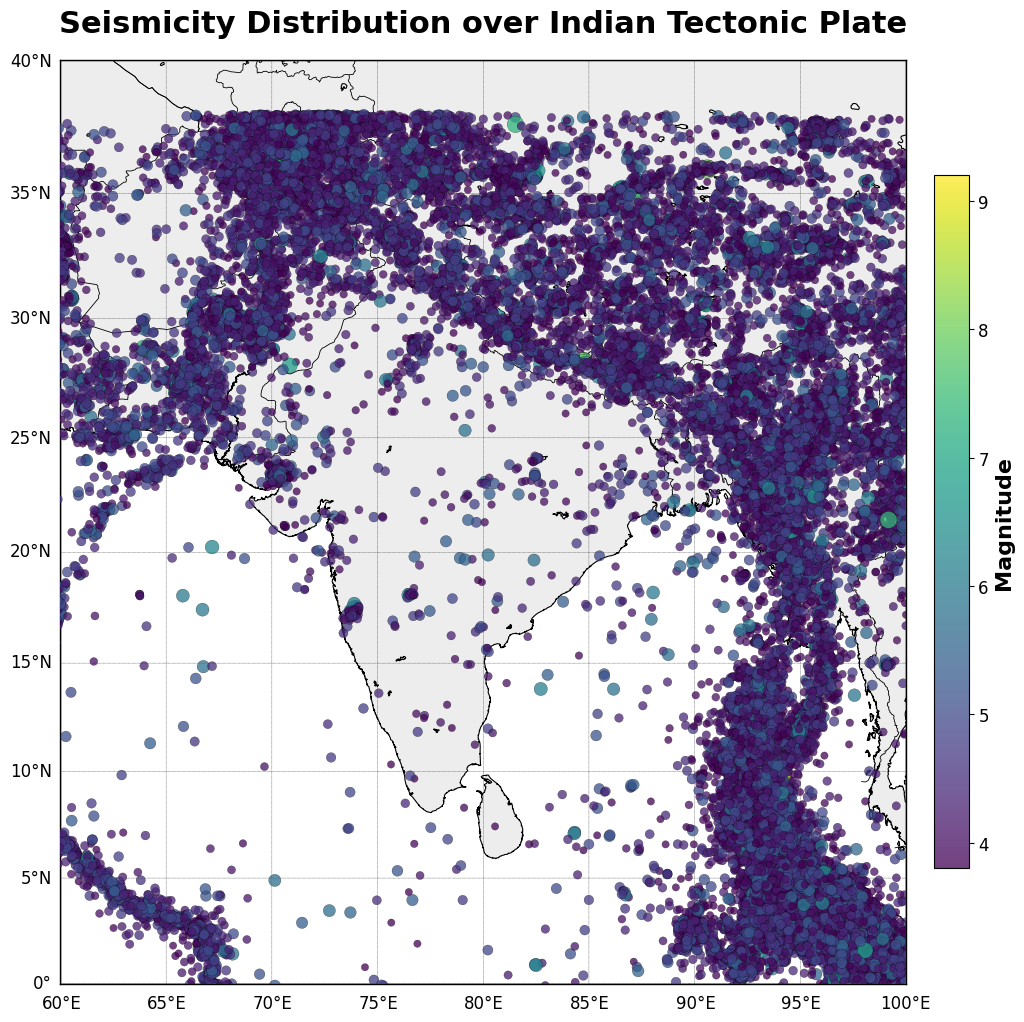

In [6]:
dpi = 600

fig, ax = plt.subplots(figsize=(18, 12))

m = Basemap(
    projection='merc',
    llcrnrlon=60,
    llcrnrlat=0,
    urcrnrlon=100,
    urcrnrlat=40,
    resolution='i',
    ax=ax
)

m.drawcoastlines(linewidth=0.8)
m.drawcountries(linewidth=0.6)

m.fillcontinents(
    color='lightgray',
    lake_color='white',
    alpha=0.4
)

m.drawmapboundary(fill_color='white')

m.drawparallels(
    np.arange(0, 41, 5),
    labels=[1, 0, 0, 0],
    fontsize=12,
    linewidth=0.3
)

m.drawmeridians(
    np.arange(60, 101, 5),
    labels=[0, 0, 0, 1],
    fontsize=12,
    linewidth=0.3
)

x, y = m(lon.values, lat.values)

msize = mag ** 2.5

sc = m.scatter(
    x,
    y,
    c=mag,
    s=msize,
    cmap='viridis',
    alpha=0.75,
    edgecolors='black',
    linewidths=0.2,
    zorder=5
)

cbar = plt.colorbar(
    sc,
    shrink=0.75,
    pad=0.02
)

cbar.set_label(
    'Magnitude',
    fontsize=16,
    fontweight='bold'
)

cbar.ax.tick_params(labelsize=12)

plt.title(
    'Seismicity Distribution over Indian Tectonic Plate',
    fontsize=22,
    fontweight='bold',
    pad=20
)

plt.savefig(
    '/content/drive/MyDrive/Project 4/indian_plate_seismicity_map.jpg',
    dpi=dpi,
    bbox_inches='tight'
)

plt.show()

## 7. Load Dataset for Seismic Energy Analysis

In [7]:
df2 = pd.read_csv('/content/drive/MyDrive/Project 4/data.csv')

df2.head()

,Longitude,Latitude,Decimal year,Month,Day,Magnitude,Depth,Hour,Minute,Second
0,95.96,3.03,1960.005376,1,2,5.0,0.0,5,6,0.0
1,94.70,6.53,1960.018817,1,7,5.9,0.0,8,15,0.0
2,94.68,6.67,1960.018817,1,7,6.0,0.0,23,17,0.0
3,70.08,36.47,1960.024194,1,9,6.7,231.0,7,24,0.0
4,95.99,16.10,1960.029570,1,11,5.8,0.0,3,10,0.0


## 8. Compute Seismic Moment

In [8]:
df2.loc[:, 'Seismic Moment'] = 10 ** (1.5 * (df2['Magnitude'] + 6))

df2[['Magnitude', 'Seismic Moment']].head()

,Magnitude,Seismic Moment
0,5.0,3.162278e+16
1,5.9,7.079458e+17
2,6.0,1.000000e+18
3,6.7,1.122018e+19
4,5.8,5.011872e+17


## 9. Compute Seismic Energy

In [9]:
df2.loc[:, 'Seismic Energy'] = 1.6 * (10 ** -5) * df2['Seismic Moment']

df2[['Magnitude', 'Seismic Moment', 'Seismic Energy']].head()

,Magnitude,Seismic Moment,Seismic Energy
0,5.0,3.162278e+16,5.059644e+11
1,5.9,7.079458e+17,1.132713e+13
2,6.0,1.000000e+18,1.600000e+13
3,6.7,1.122018e+19,1.795230e+14
4,5.8,5.011872e+17,8.018996e+12


## 10. Annual Seismic Energy Release

In [10]:
df2['Year'] = np.trunc(df2['Decimal year']).astype(int)

df = df2.groupby(['Year'])['Seismic Energy'].sum().reset_index()

df = df.sort_values(by='Year')

df.head()

,Year,Seismic Energy
0,1960,9.147006e+14
1,1961,6.182369e+14
2,1962,8.140676e+14
3,1963,2.661863e+14
4,1964,8.626869e+14


## 11. Plot Annual Seismic Energy

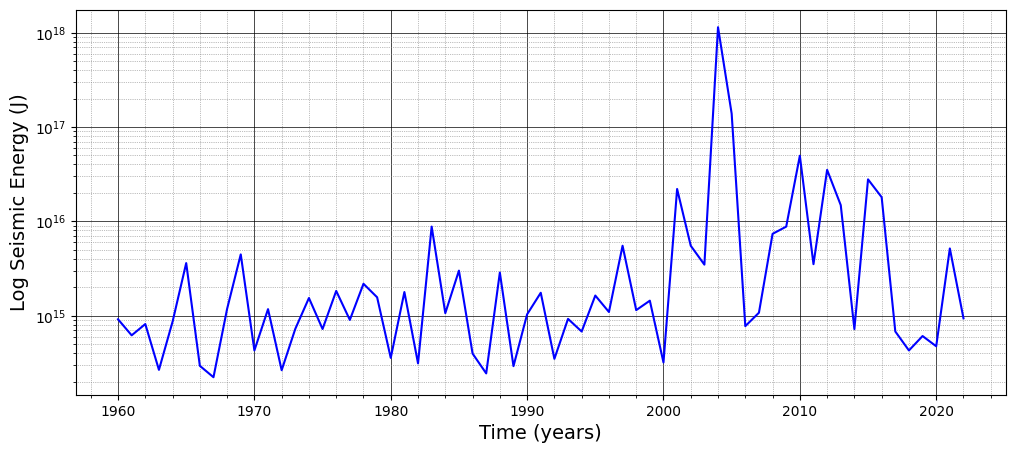

In [12]:
plt.figure(figsize=(12, 5))

plt.yscale('log')

plt.plot(
    df['Year'],
    df['Seismic Energy'],
    linestyle='-',
    color='b'
)

plt.xlabel('Time (years)', fontsize=14)
plt.ylabel('Log Seismic Energy (J)', fontsize=14)

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

plt.minorticks_on()

plt.grid(True)

plt.savefig(
    '/content/drive/MyDrive/Project 4/Seismic_Energy_Graph.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

## 12. Export Processed Dataset

In [13]:
df2.to_csv(
    '/content/drive/MyDrive/Project 4/Processed_Seismic_Energy_Data.csv',
    index=False
)

print('Processed seismic energy dataset exported successfully.')

Processed seismic energy dataset exported successfully.


# Applications

- Seismic hazard assessment
- Earthquake forecasting
- Seismotectonic investigations
- Machine learning applications in seismology
- Spatial seismicity analysis


# References

1. Hanks, T. C., & Kanamori, H. (1979). A moment magnitude scale.

2. Choy, G. L., & Boatwright, J. (1995). Global patterns of radiated seismic energy.

3. Yarramsetty, B. B., & Baladhandapani, K. (2026). Machine Learning Models for Seismic Energy Forecasting and Spatial Correlation Analysis for the Himalayan and Indo-Burmese Regions.

4. Yarramsetty, B. B., & Baladhandapani, K. (2026). Data-driven prediction of global annual seismic energy using machine learning models.

5. Bala Balaji, Y., Hema Sundara, R. V., & Kavitha, B. (2025). Spatial Variation of Seismic Energy Release of Himachal Pradesh.

6. Yarramsetty, B. B., & Kavitha, B. (2025). Statistical Study on Seismicity of the Indian Tectonic Plate Interactions.


# Conclusion

This notebook successfully demonstrates:

- Spatial visualization of Indian tectonic plate seismicity
- Seismic energy estimation from earthquake magnitude
- Annual seismic energy release analysis
- Scientific geospatial visualization techniques
